# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("C:/Users/Admin/Documents/Full_Stack_Internship/csv/Customers.csv")
df

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...,...
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2


# DATA SUMMARY

VIEW DATASET

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


CHECK SHAPES

In [4]:
df.shape

(2000, 8)

CHECK COLUMN VALUES

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income ($)',
       'Spending Score (1-100)', 'Profession', 'Work Experience',
       'Family Size'],
      dtype='str')

CHECK DATA INFORMATION

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              2000 non-null   int64
 1   Gender                  2000 non-null   str  
 2   Age                     2000 non-null   int64
 3   Annual Income ($)       2000 non-null   int64
 4   Spending Score (1-100)  2000 non-null   int64
 5   Profession              1965 non-null   str  
 6   Work Experience         2000 non-null   int64
 7   Family Size             2000 non-null   int64
dtypes: int64(6), str(2)
memory usage: 151.2 KB


SUMMARY

In [7]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


CHECK DATA TYPES

In [8]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income ($)         int64
Spending Score (1-100)    int64
Profession                  str
Work Experience           int64
Family Size               int64
dtype: object

# DATA CLEANING

CHECK AND REMOVE DUPLICATE VALUES

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

In [10]:
df.duplicated().sum()          


np.int64(0)

In [11]:
df= df.drop_duplicates()

NULL VALUES

In [12]:
df.isna()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()


CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(35)

REMOVE NULL VALUES

In [15]:
df=df.dropna(subset=['Profession'])

In [16]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64

In [17]:
df.shape

(1965, 8)

STANDARTIZE TEXT COLUMN

In [18]:
df['Gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [19]:
df['Profession'].unique()

<ArrowStringArray>
[   'Healthcare',      'Engineer',        'Lawyer', 'Entertainment',
        'Artist',     'Executive',        'Doctor',     'Homemaker',
     'Marketing']
Length: 9, dtype: str

SAVE CLEANED DATA

In [20]:
df.to_csv("c:/Users/Admin/Documents/Full_Stack_Internship/csv/Customers_cleaned.csv", index=False)

# Encoding

Label Encoder(Gender)

In [21]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
df['Gender'] = gender_encoder.fit_transform(df['Gender'])

profession_encoder = LabelEncoder()
df['Profession'] = profession_encoder.fit_transform(df['Profession'])

# DATA VISUALIZATION

#1. Age Distribution (Histogram)

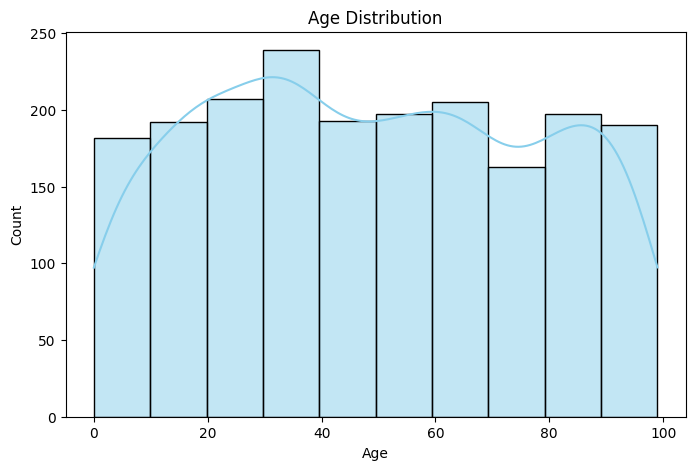

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.show()

#2. Gender Count (count plot)

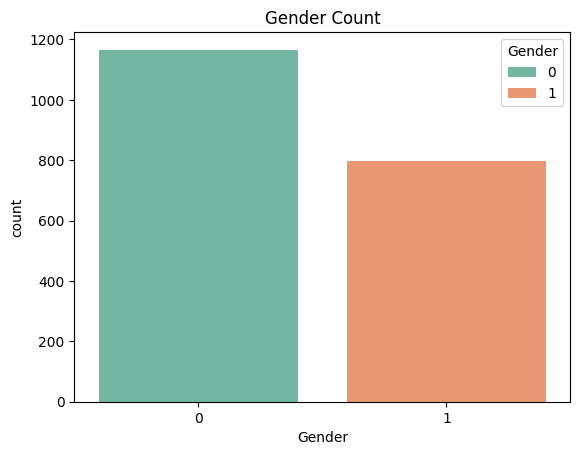

In [23]:
sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2', legend=True)
plt.title("Gender Count")
plt.show()

#3.Income vs Spending Score(Scatter)

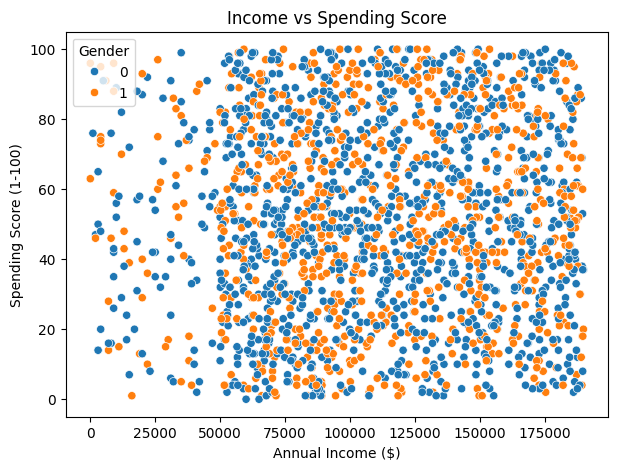

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Annual Income ($)', y='Spending Score (1-100)', hue='Gender', data=df)
plt.title("Income vs Spending Score")
plt.show()

#4.Family Size vs Income (Box Plot)

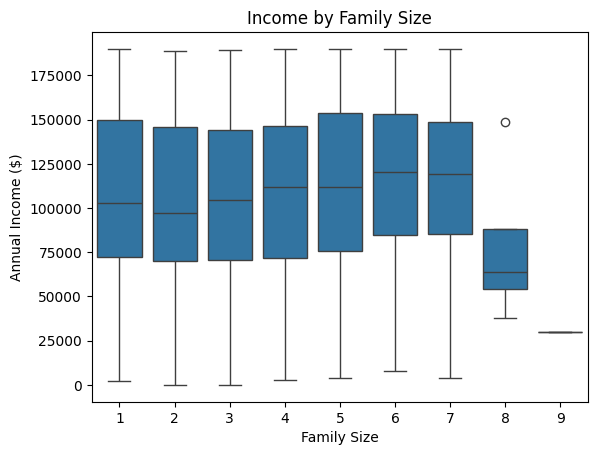

In [25]:
sns.boxplot(x='Family Size', y='Annual Income ($)', data=df)
plt.title("Income by Family Size")
plt.show()

#5. Pair Plot

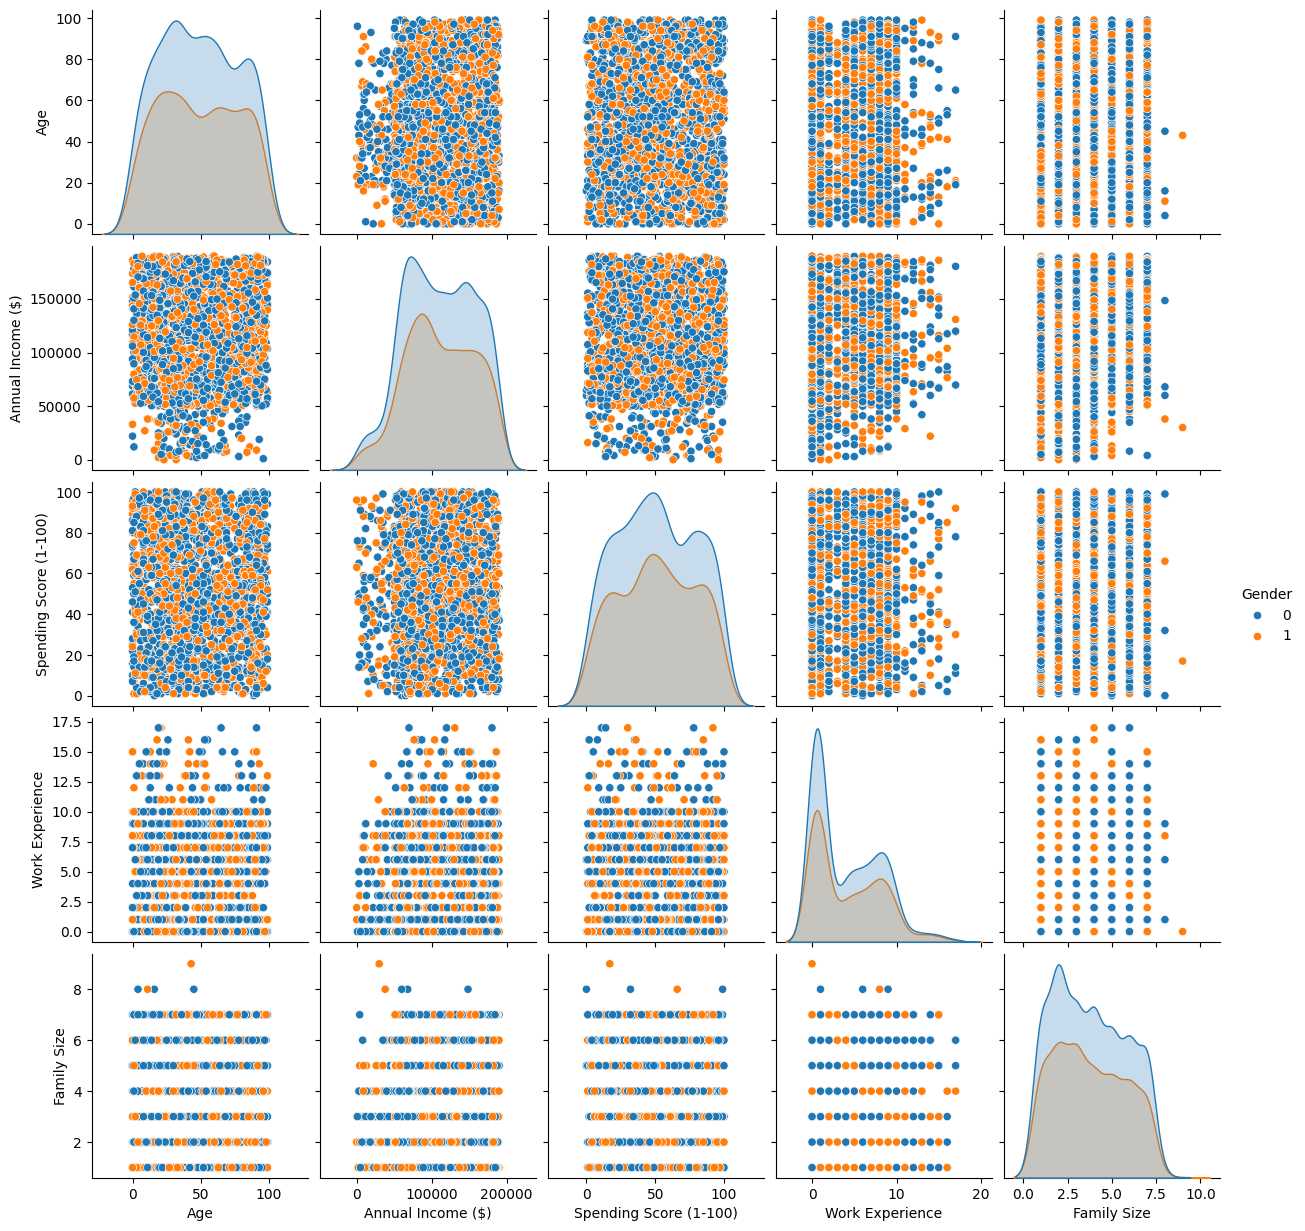

In [26]:
sns.pairplot(df[['Age','Annual Income ($)','Spending Score (1-100)','Work Experience','Family Size','Gender']], hue='Gender')
plt.show()

#6.Trend using grouped data( Line Plot )

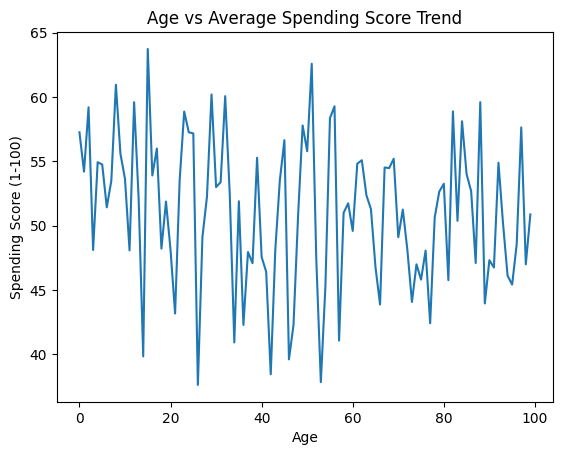

In [27]:
avg_spend = df.groupby('Age')['Spending Score (1-100)'].mean().reset_index()

sns.lineplot(x='Age', y='Spending Score (1-100)', data=avg_spend)
plt.title("Age vs Average Spending Score Trend")
plt.show()

#7.Correlation Matrix(Heatmap)

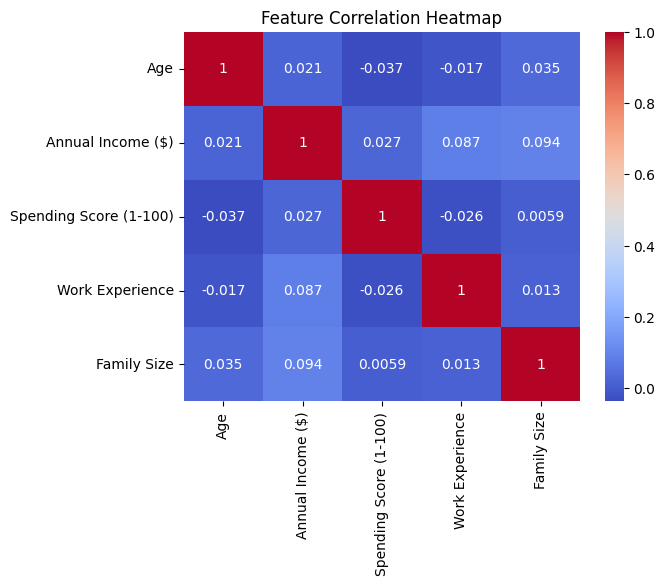

In [28]:
corr = df[['Age','Annual Income ($)','Spending Score (1-100)','Work Experience','Family Size']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

#8.Gender Distribution(Pie Chart)

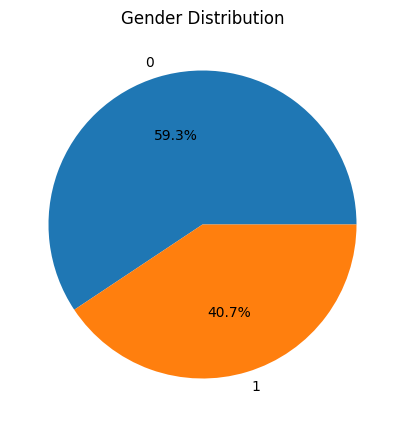

In [29]:
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5))
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

#9.Average Work Experience by Gender(Bar plot)

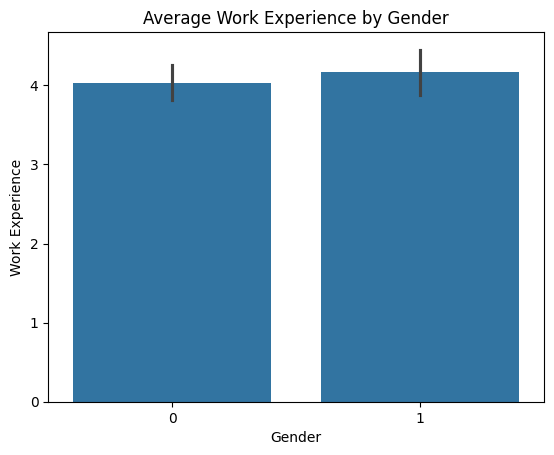

In [30]:
sns.barplot(x='Gender', y='Work Experience', data=df)

plt.title('Average Work Experience by Gender')
plt.show()

#10.Average Spending Score by Age(Area Plot)

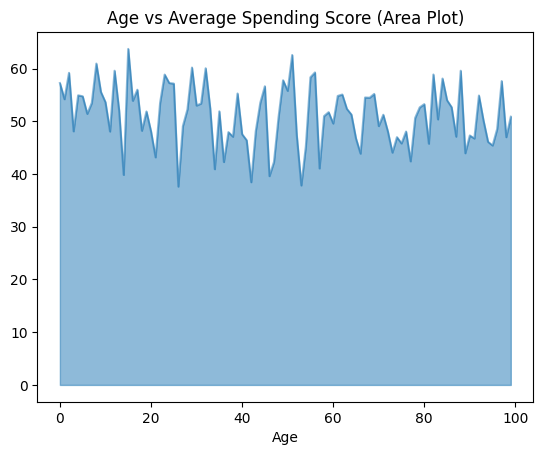

In [31]:
df.groupby('Age')['Spending Score (1-100)'].mean().plot(kind='area', alpha=0.5)
plt.title("Age vs Average Spending Score (Area Plot)")
plt.show()

#11.Annual Income by Family Size(violin Plot)

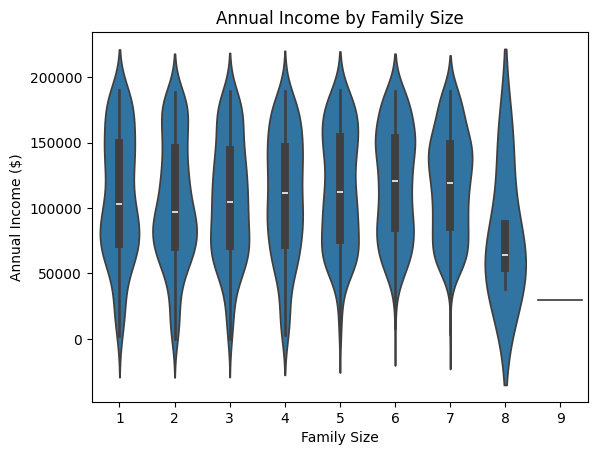

In [32]:
sns.violinplot(x='Family Size', y='Annual Income ($)', data=df)

plt.title('Annual Income by Family Size')
plt.show()

# FEATURE ENGINEERING

CREATE Income_Per_Family

In [33]:
df['Income_Per_Family'] = df['Annual Income ($)'] / df['Family Size'].replace(0, 1)

CREATE Experience_Ratio

In [34]:
df['Experience_Ratio'] = df['Work Experience'] / df['Age'].replace(0, 1)

GROUPBY AND AGGREGATE

In [35]:
df.groupby('Gender').agg({
    'Annual Income ($)': 'mean'
})

,Annual Income ($)
Gender,
0,110434.875643
1,110880.342929


In [36]:
df

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Income_Per_Family,Experience_Ratio
0,1,1,19,15000,39,5,1,4,3750.000000,0.052632
1,2,1,21,35000,81,2,3,3,11666.666667,0.142857
2,3,0,20,86000,6,2,1,1,86000.000000,0.050000
3,4,0,23,59000,77,7,0,2,29500.000000,0.000000
4,5,0,31,38000,40,3,2,6,6333.333333,0.064516
...,...,...,...,...,...,...,...,...,...,...
1995,1996,0,71,184387,40,0,8,7,26341.000000,0.112676
1996,1997,0,91,73158,32,1,7,7,10451.142857,0.076923
1997,1998,1,87,90961,14,5,9,2,45480.500000,0.103448
1998,1999,1,77,182109,4,4,7,2,91054.500000,0.090909


CHECK NEW COLUMNS

In [37]:
print(df.head())

   CustomerID  Gender  Age  Annual Income ($)  Spending Score (1-100)  \
0           1       1   19              15000                      39   
1           2       1   21              35000                      81   
2           3       0   20              86000                       6   
3           4       0   23              59000                      77   
4           5       0   31              38000                      40   

   Profession  Work Experience  Family Size  Income_Per_Family  \
0           5                1            4        3750.000000   
1           2                3            3       11666.666667   
2           2                1            1       86000.000000   
3           7                0            2       29500.000000   
4           3                2            6        6333.333333   

   Experience_Ratio  
0          0.052632  
1          0.142857  
2          0.050000  
3          0.000000  
4          0.064516  


In [38]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income ($)',
       'Spending Score (1-100)', 'Profession', 'Work Experience',
       'Family Size', 'Income_Per_Family', 'Experience_Ratio'],
      dtype='str')


# FEATURE SELECTION

1. CHECK COLUMN VALUES

In [39]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'Age',
 'Annual Income ($)',
 'Spending Score (1-100)',
 'Profession',
 'Work Experience',
 'Family Size',
 'Income_Per_Family',
 'Experience_Ratio']

2.DROP CUSTOMER ID

In [40]:
df = df.drop('CustomerID', axis=1)

3.DEFINE FEATURES AND TARGET

In [41]:
X = df.drop('Spending Score (1-100)', axis=1)
y = df['Spending Score (1-100)']

4.CORRELATION WITH TARGET

In [42]:
corr_with_target=df.corr(numeric_only=True)['Spending Score (1-100)'].sort_values(ascending=False)
print(corr_with_target)

Spending Score (1-100)    1.000000
Annual Income ($)         0.026716
Family Size               0.005859
Gender                    0.003703
Experience_Ratio         -0.000942
Income_Per_Family        -0.005840
Work Experience          -0.025587
Age                      -0.037387
Profession               -0.046437
Name: Spending Score (1-100), dtype: float64


5.FINAL FEATURE SET

In [43]:
X.shape


(1965, 8)

In [44]:
X.head()

,Gender,Age,Annual Income ($),Profession,Work Experience,Family Size,Income_Per_Family,Experience_Ratio
0,1,19,15000,5,1,4,3750.000000,0.052632
1,1,21,35000,2,3,3,11666.666667,0.142857
2,0,20,86000,2,1,1,86000.000000,0.050000
3,0,23,59000,7,0,2,29500.000000,0.000000
4,0,31,38000,3,2,6,6333.333333,0.064516


# DATA SPLIT/PARTITION

In [45]:
from sklearn.model_selection import train_test_split


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1572, 8)
X_test shape: (393, 8)
y_train shape: (1572,)
y_test shape: (393,)


# DATA TRANSFORMATION

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL INITIALIZATION

In [49]:
from sklearn.svm import SVR

model = SVR(kernel='rbf')

# MODEL TRAINING

In [50]:
model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


# MODEL PREDICTION

In [51]:
y_pred = model.predict(X_test_scaled)

# MODEL EVALUATION

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 23.474299052924202
MSE: 753.6477888756975
R2 Score: 0.009355237765738988


# MODEL VISUALIZATION

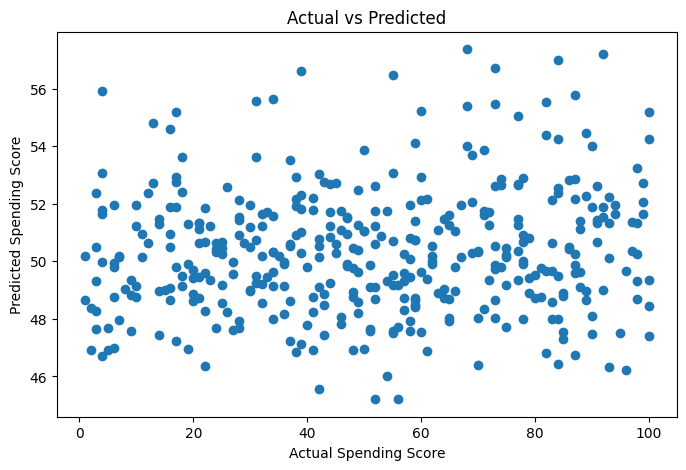

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Spending Score")
plt.ylabel("Predicted Spending Score")
plt.title("Actual vs Predicted")
plt.show()

# MODEL DEPLOYMENT

Save the trained SVR model

In [54]:
import pickle

with open('svr_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model exported successfully!")

Model exported successfully!


Save the scaler too

In [55]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler exported successfully!")

Scaler exported successfully!


Save encoders

In [56]:

with open('gender_encoder.pkl', 'wb') as file:
    pickle.dump(gender_encoder, file)

print("Gender Encoder Saved")

Gender Encoder Saved


In [57]:


with open('profession_encoder.pkl', 'wb') as file:
    pickle.dump(profession_encoder, file)

print("Profession Encoder Saved")

Profession Encoder Saved


# MODEL EXPORT

In [58]:
import pickle

# Load model
with open('svr_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Load scaler
with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

#load encoders
with open('gender_encoder.pkl', 'rb') as file:
    gender_encoder = pickle.load(file)

with open('profession_encoder.pkl', 'rb') as file:
    profession_encoder = pickle.load(file)

# Predict using scaled test data
y_pred = loaded_model.predict(X_test_scaled)

print(y_pred)

[47.64631197 51.97134298 46.95623819 51.31966416 51.38552512 51.9024125
 49.91956298 49.08330982 48.61600258 48.69305787 52.17387804 50.39051544
 51.49077308 50.63697996 47.49405131 50.50464587 55.05560972 46.42788652
 52.72410479 51.97043117 52.76831598 50.13870707 49.98812275 51.73350789
 49.77565613 48.96922352 50.43222397 49.81117179 56.49006634 49.19815358
 47.2448353  47.78651933 52.11944224 50.66346201 51.10829839 48.74503777
 51.02028163 46.92475351 50.1048336  48.6436311  48.96327299 51.95442231
 49.24849047 50.31243474 50.23333047 49.79107385 49.87363583 51.21347061
 47.58161894 49.90657304 50.52138223 52.14043711 49.58299263 57.36942336
 48.01621923 49.18817023 49.84971717 52.54426283 51.64369427 52.87702308
 51.9580681  50.64706937 50.26169443 51.80863293 49.33641621 47.98885077
 50.0129583  50.17527821 52.4148536  49.53723398 47.64903428 51.09895589
 49.86278525 52.17319965 51.8593095  50.19979771 52.20879713 50.54049144
 50.50955724 50.1784076  49.11479013 46.72306009 53.

CHECK COLUMN NAMES

In [59]:
print(X.columns.tolist())
print(len(X.columns))

['Gender', 'Age', 'Annual Income ($)', 'Profession', 'Work Experience', 'Family Size', 'Income_Per_Family', 'Experience_Ratio']
8


In [60]:
import sys
print(sys.executable)

c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [61]:
import matplotlib.pyplot as plt
print("Matplotlib Working")

Matplotlib Working
